In [548]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.constants import k as k_B
import itertools

In [549]:
def mean_vel(m, T):
  return np.sqrt(8 * k_B * T / (np.pi * m))

# special case where the mass of these is the same
def mean_rel_vel(m, T):
  return np.sqrt(2) * mean_vel(m, T)

In [550]:
T_0 = 273.15
T_12 = 373.15
T_0s = [T_0, T_12, T_12]
T_eq = (T_0 + 2 * T_12) / 3
m = 1e-20

# maxwell reference value
sigma_0 = 1
# hard sphere value
sigma_t = 2/3
diameter = np.sqrt(sigma_t / np.pi)
n = 1

v_bar = mean_vel(m, T_eq)
v_rel_bar = mean_rel_vel(m, T_eq)

sigma_g_bar_maxwell = sigma_0
sigma_g_bar_hard_sphere = sigma_t * v_rel_bar

def collision_params(n, sigma_g_bar, v_bar, collision_type):
  print(f"Collision Type: {collision_type}")
  collision_frequency = n * sigma_g_bar
  mean_free_path = v_bar / collision_frequency
  mean_collision_time = 1 / collision_frequency

  print(f"Collision Frequency : {collision_frequency} Hz")
  print(f"Mean Collision Time : {mean_collision_time} s")
  print(f"Mean Free Path      : {mean_free_path} m")


  dt = 1 / 4 * mean_collision_time
  dx = 1 / 3 * mean_free_path

  print(f"Time Step Estimate  : {dt} s")
  print(f"Cell Size Estimate  : {dx} m")
  print()
  print()
  return dt, collision_frequency


dt_maxwell, collision_frequency_maxwell = collision_params(n, sigma_g_bar_maxwell, v_bar, "Maxwell")
dt_hard_sphere, collision_frequency_hard_sphere = collision_params(n, sigma_g_bar_hard_sphere, v_bar, "Hard Sphere")
print(f"Hard Sphere Diameter : {diameter}")

Collision Type: Maxwell
Collision Frequency : 1 Hz
Mean Collision Time : 1.0 s
Mean Free Path      : 1.093034918315583 m
Time Step Estimate  : 0.25 s
Cell Size Estimate  : 0.36434497277186095 m


Collision Type: Hard Sphere
Collision Frequency : 1.0305232037528436 Hz
Mean Collision Time : 0.9703808670763671 s
Mean Free Path      : 1.0606601717798214 m
Time Step Estimate  : 0.24259521676909176 s
Cell Size Estimate  : 0.3535533905932738 m


Hard Sphere Diameter : 0.46065886596178063


In [551]:
def f_M(v, T, m):
  return 4 * np.pi * v**2 * (m / (2 * np.pi * k_B * T))**(3/2) * np.exp(- m * v**2 / (2 * k_B * T))

def f_M_v(v, T, m):
  return np.sqrt((m / (2 * np.pi * k_B * T))) * np.exp(- m * v**2 / (2 * k_B * T))

In [552]:
maxwell_omega = 1
maxwell_alpha = 2.13986
maxwell_mu_inf_mu_1 = 1
maxwell_K_inf_K_1 = 1
maxwell_Pr = ( 2 / 3 ) * maxwell_mu_inf_mu_1 / maxwell_K_inf_K_1
maxwell_ratio = maxwell_alpha * (5 - 2 * maxwell_omega) * (7 - 2 * maxwell_omega) * maxwell_Pr / (5 * (maxwell_alpha + 1) * (maxwell_alpha + 2) * (maxwell_mu_inf_mu_1))
maxwell_relaxation_rate = maxwell_ratio * collision_frequency_hard_sphere
print(maxwell_ratio)

0.3292451737151792


In [553]:
hard_sphere_omega = 0.5
hard_sphere_alpha = 1
hard_sphere_mu_inf_mu_1 = 1.016034
hard_sphere_K_inf_K_1 = 1.025218
hard_sphere_Pr = ( 2 / 3 ) * hard_sphere_mu_inf_mu_1 / hard_sphere_K_inf_K_1
hard_sphere_ratio = hard_sphere_alpha * (5 - 2 * hard_sphere_omega) * (7 - 2 * hard_sphere_omega) * hard_sphere_Pr / (5 * (hard_sphere_alpha + 1) * (hard_sphere_alpha + 2) * (hard_sphere_mu_inf_mu_1))
hard_sphere_relaxation_rate = hard_sphere_ratio * collision_frequency_hard_sphere
print(hard_sphere_ratio)

0.5202145624963016


In [554]:
def f_M(v, T, m):
  return 4 * np.pi * v**2 * (m / (2 * np.pi * k_B * T))**(3/2) * np.exp(- m * v**2 / (2 * k_B * T))

def f_M_v(v, T, m):
  return np.sqrt((m / (2 * np.pi * k_B * T))) * np.exp(- m * v**2 / (2 * k_B * T))
def f_analytic(v, t, T_i0, T_eq, m, relaxation_rate):

  g  = f_M_v(v, T_eq, m)
  return  g + np.exp(-relaxation_rate * t) * (f_M_v(v, T_i0, m) - g)

def T_analytic(t, T_i0, T_eq, relaxation_rate):
  return T_eq + np.exp(-relaxation_rate * t) * (T_i0 - T_eq)

In [555]:
def readData(filepath):
  data = pd.read_csv(filepath)
  components = ["x", "y", "z"]

  centers = []
  pdf = []

  for _, c in enumerate(components):
    temp_centers = ((data[f"v_{c:s}_lower"] + data[f"v_{c:s}_upper"]) / 2).to_numpy()
    counts = data[f"v_{c:s}"]
    total = np.trapezoid(counts, temp_centers)
    centers.append(temp_centers)
    pdf.append(counts / total)
  return data, pdf, centers

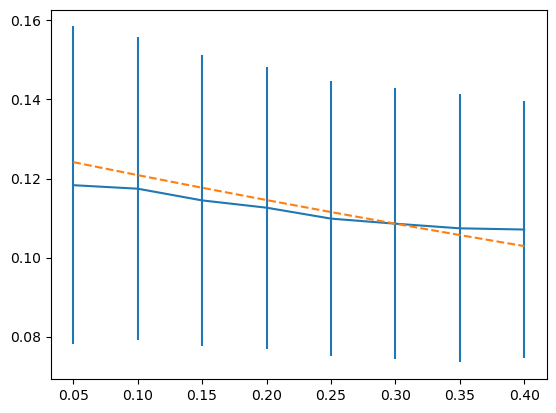

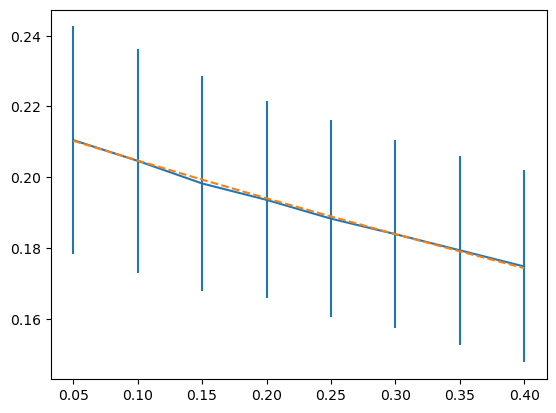

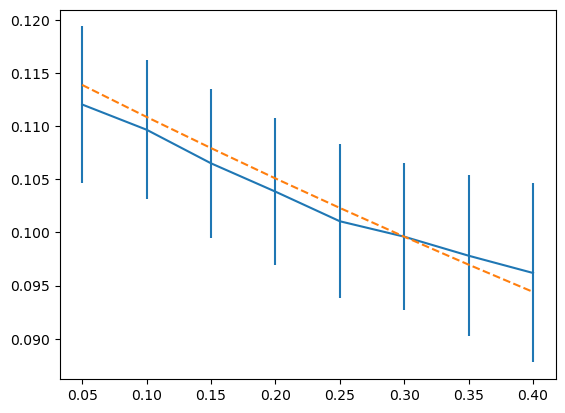

In [556]:
def multipleRuns(folder, run_start, runs, steps, step_size, T_eq, m):
    centers = None
    widths = None
    counts = None
    components = ["x", "y", "z"]
    errors = np.zeros((3, int(steps / step_size) - 1, runs), dtype=float)
    f_equilibrium = None


    for i, step in enumerate(range(step_size, steps, step_size)):
        for j in range(runs):
            file_name = f"{folder:s}/run_{j + run_start}_distribution_{step:04d}.csv"
            #file_name =  f"testing_csv_distribution_{step:04d}.csv"
            data = pd.read_csv(file_name)
            if i == 0 and j == 0:
                lower = data["v_x_lower"].to_numpy()
                upper = data["v_x_upper"].to_numpy()
                centers = (lower + upper) / 2
                widths = (upper - lower)
                f_equilibrium = f_M_v(centers, T_eq, m)
                counts = [[np.zeros_like(lower) for _ in range(3)] for _ in range(step_size, steps, step_size)]
            for k, component in enumerate(components):
                vals = data[f"v_{component}"].to_numpy(dtype=float)
                total = np.trapezoid(vals, centers)
                pdf = vals / total
                errors[k][i][j] = np.linalg.norm(f_equilibrium - pdf)
                counts[i][k] += vals
    for step_counts in counts:
        for component_count in step_counts:
            component_count /= np.trapezoid(component_count, centers)
    return centers, counts, widths, errors

dt = 1e-2
num_steps = 45
step_size = 5
run_start = 0
times = np.arange(step_size, num_steps, step_size) * dt

centers, counts, widths, errors = multipleRuns("hard_sphere/10x10/400_ppe", 10, 10, num_steps, step_size, T_eq,m )
expected_rate = hard_sphere_relaxation_rate
#expected_rate =  maxwell_relaxation_rate
#centers, counts, widths, errors = multipleRuns(".", 1, 100, 5, T_eq,m )


fit_index = 5
rates = np.zeros((3), dtype=float)
for i in range(3):
    component_errors = errors[i]
    mean_error = component_errors.mean(axis=1)
    expected = mean_error[fit_index] * np.exp(-expected_rate * (times - times[fit_index]))
    simulated_rate, _ = np.polyfit(times, np.log(mean_error), deg=1)
    rates[i] = np.abs(simulated_rate)
    plt.figure()
    plt.errorbar(times, mean_error, component_errors.std(axis=1))
    plt.plot(times, expected,'--', zorder=10)
    plt.show()

In [557]:
print(f"Expected Rate    :  {expected_rate:0.4E}")
print()
for i, rate in enumerate(rates):
  print(f"Component {i} Rate : {rate:0.4E}")
  print(f"   Percent Error : {100 * np.abs(rate - expected_rate) / expected_rate:0.4E}")
  print()

Expected Rate    :  5.3609E-01

Component 0 Rate : 3.1584E-01
   Percent Error : 4.1086E+01

Component 1 Rate : 5.2704E-01
   Percent Error : 1.6896E+00

Component 2 Rate : 4.4503E-01
   Percent Error : 1.6987E+01



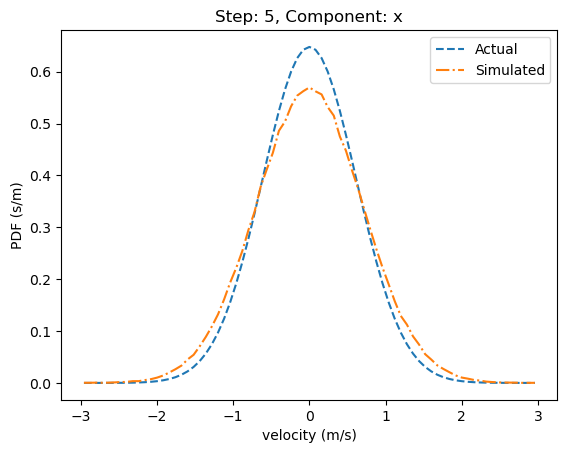

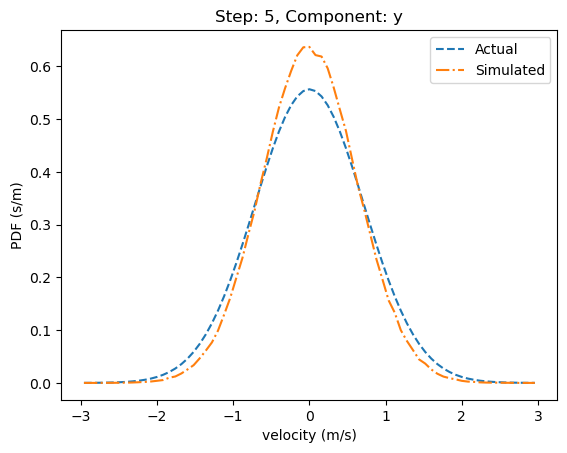

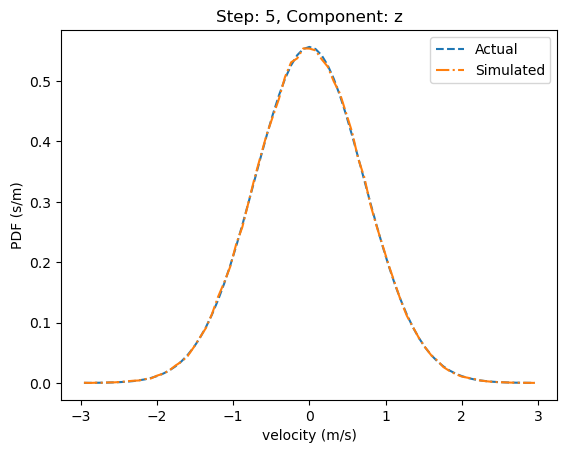

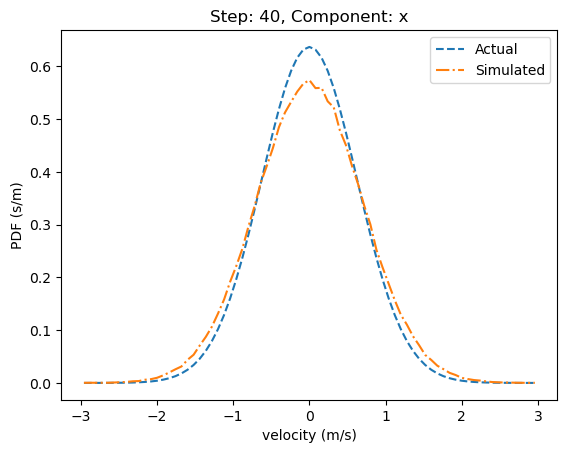

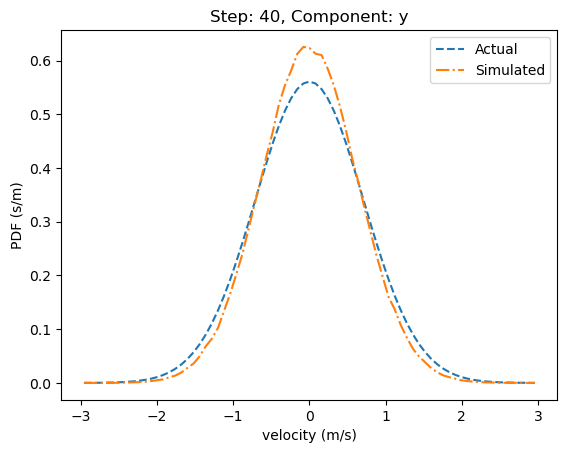

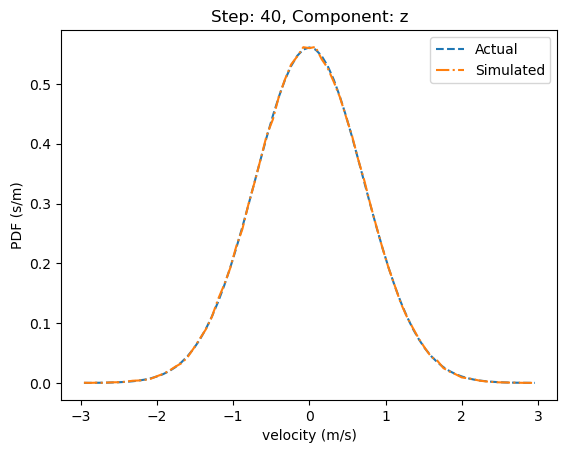

In [558]:

def compareToAnswer(centers, counts, widths, dt, step_size, T_0s, T_eq, m, relaxation_rate):
    components = ["x", "y", "z"]
    errors = np.zeros((3, len(counts)), dtype=float)
    for i, pdfs in enumerate(counts):
      for j, (pdf, (T_i0, component)) in enumerate(zip(pdfs, zip(T_0s, components))):
          t = dt * ((i + 1) * step_size)
          f_expected = f_analytic(centers, t, T_i0, T_eq, m, relaxation_rate)
          f_equilibrium = f_M_v(centers, T_eq, m)
          if i == 0 or i == len(counts) - 1:
              plt.figure()
              plt.plot(centers, f_expected, '--', label='Actual')
              plt.plot(centers, pdf, '-.', label='Simulated')
              plt.ylabel("PDF (s/m)")
              plt.xlabel("velocity (m/s)")
              plt.title(f"Step: {(i + 1) * step_size}, Component: {component}")
              plt.legend()
              plt.show()

          errors[j][i] = np.linalg.norm(pdf - f_equilibrium)
    return errors
errors = compareToAnswer(centers, counts, widths, dt, 5, T_0s, T_eq, m, expected_rate)


[0.05922056 0.05872214 0.05706151 0.05544208 0.05411373 0.05194941
 0.05090004 0.05104061]


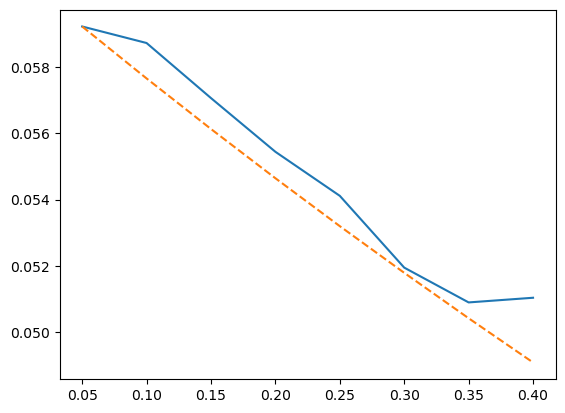

[0.18117673 0.17571173 0.16992674 0.16410477 0.15948074 0.15465937
 0.15096345 0.14740461]


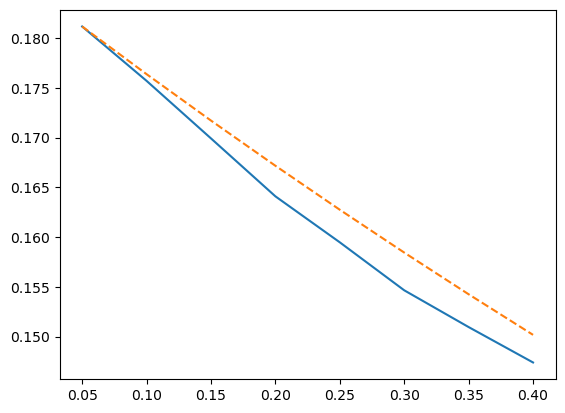

[0.09487904 0.09240222 0.08857803 0.08599224 0.08320939 0.08097864
 0.07848941 0.07663961]


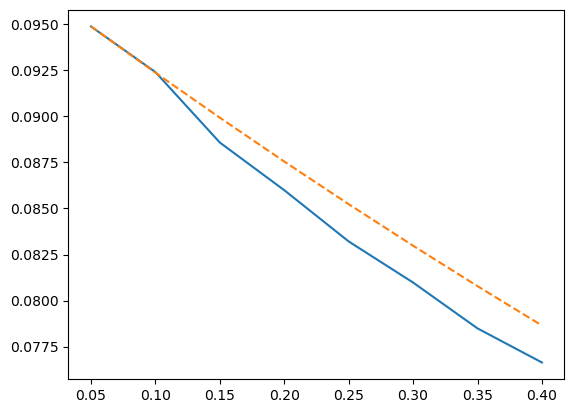

In [559]:

for i in range(3):
    component_error = errors[i]
    expected = component_error[0] * np.exp( - expected_rate * (times - times[0]))
    print(component_error)
    plt.figure()
    plt.plot(times, component_error)
    plt.plot(times, expected, '--')
    plt.show()